In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg  # For loading images

# File operations
import os
import shutil

# Image processing
import cv2  # OpenCV

# Jupyter-specific plotting
%matplotlib inline
plt.style.use('ggplot')  # nice chart style

In [2]:
folder = './data/brain_tumor_dataset/yes/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + 'Y_' + str(count) + '.jpg'
    os.rename(source, destination)
    count+=1
print('All file are renamed in the yes dir')

All file are renamed in the yes dir


In [3]:
folder = './data/brain_tumor_dataset/no/'
count = 1
for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + 'N_' + str(count) + '.jpg'
    os.rename(source, destination)
    count+=1
print('All file are renamed in the no dir')

All file are renamed in the no dir


EDA(Exploratory Data Analysis)

In [4]:
list_yes = os.listdir('./data/brain_tumor_dataset/yes/')
number_files_yes = len(list_yes)
number_files_yes

38

In [5]:
list_no = os.listdir('./data/brain_tumor_dataset/no/')
number_files_no = len(list_no)
number_files_no

27

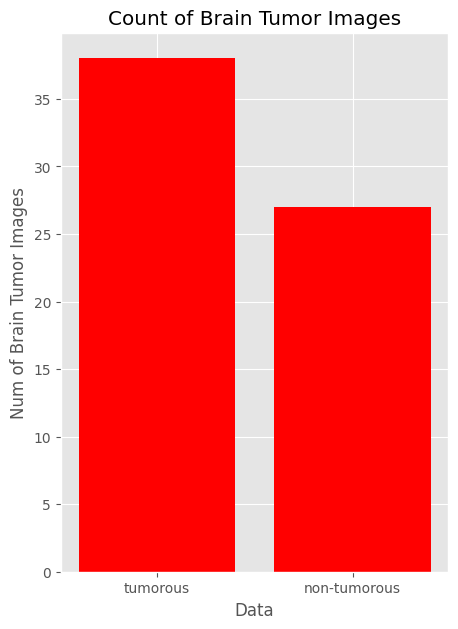

In [6]:
data = {
    'tumorous': number_files_yes,
    'non-tumorous': number_files_no
}
typeex = data.keys()
values = data.values()
fig = plt.figure(figsize=(5, 7))
plt.bar(typeex, values, color='red')
plt.xlabel('Data')
plt.ylabel('Num of Brain Tumor Images')
plt.title('Count of Brain Tumor Images')
plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

2026-03-03 00:42:06.523779: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 00:42:06.523999: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 00:42:06.566556: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 00:42:07.616974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [8]:
# Function to generate augmented images from a folder of images
def augmented_data(file_dir, n_generated_sample, save_to_dir):
    
    # Create an ImageDataGenerator object which will apply random transformations to images
    data_gen = ImageDataGenerator(
        rotation_range=10,          
        width_shift_range=0.1,     
        height_shift_range=0.1,    
        shear_range=0.1,            # apply shear transformation (slanting) randomly
        brightness_range=(0.1, 0.3),
        horizontal_flip=True,      
        fill_mode='nearest'    
    )

    for filename in os.listdir(file_dir):
        img = cv2.imread(file_dir + '/' + filename)
        
        # Reshape the image to add a batch(grp of images processed together) dimension (required by Keras)
        # Example: from (224, 224, 3) to (1, 224, 224, 3)
        img = img.reshape((1,) + img.shape)
        
        save_prefix = 'aug_' + filename[:4]
        
        i = 0
        
        # Generate augmented images in a loop
        # data_gen.flow creates an infinite generator that applies random transformations
        for batch in data_gen.flow(
                x=img,                
                batch_size=1,          # generate 1 image per iteration (batch = 1 image)
                save_to_dir=save_to_dir, 
                save_prefix=save_prefix, 
                save_format='jpg'       
        ):
            i += 1 
            
            if i > n_generated_sample:
                break 

In [10]:
yes_path = './data/brain_tumor_dataset/yes'
no_path = './data/brain_tumor_dataset/no'
augmented_data_path = './data/augmented_data/'

augmented_data(yes_path, 6, augmented_data_path + 'yes')
augmented_data(no_path, 6, augmented_data_path + 'no')

In [ ]:
def data_summary(main_path):
    yes_path = './data/augmented_data/yes/'
    no_path = './data/augmented_data/no/'
    